In [378]:
import numpy as np
from math import floor, ceil
from matplotlib import pyplot as plt
import seaborn as sns
import tqdm

In [329]:
def primesfrom2to(n):
    # https://stackoverflow.com/questions/2068372/fastest-way-to-list-all-primes-below-n-in-python/3035188#3035188
    """ Input n>=6, Returns a array of primes, 2 <= p < n """
    sieve = np.ones(int(n/3) + (n%6==2), dtype=bool)
    sieve[0] = False
    for i in range(int(int(n**0.5)/3+1)):
        if sieve[i]:
            k=3*i+1|1
            sieve[      int((k*k)/3)      ::2*k] = False
            sieve[int((k*k+4*k-2*k*(i&1))/3)::2*k] = False
    return np.r_[2,3,((3*np.nonzero(sieve)[0]+1)|1)]

In [330]:
primesfrom2to(7)

array([2, 3, 5])

In [379]:
size = 1000
prime_limit = 200000
x = np.zeros(size, dtype=int)
x[0] = 0
x[1] = 1
for k in tqdm.trange(2, size):
    if np.any(np.floor(k/primesfrom2to(prime_limit)).astype(int) >= k):
        raise Exception(f"{k} - Brema")
    if np.any(x[np.floor(k/primesfrom2to(prime_limit)).astype(int)] >= k):
        raise Exception(f"{k} - Brema 2")
    
    indices = np.floor(k/primesfrom2to(prime_limit)).astype(int)
    #print(indices, x[indices], x[x[indices]])
    x[k] = x[x[np.floor(k/primesfrom2to(prime_limit)).astype(int)]].sum()


100%|████████████████████████████████████████| 998/998 [00:01<00:00, 614.22it/s]


In [380]:
x

array([  0,   1,   1,   2,   2,   3,   3,   4,   4,   4,   5,   6,   6,
         7,   7,   8,   8,   9,   9,  10,  11,  11,  11,  12,  12,  13,
        14,  14,  14,  15,  16,  17,  17,  17,  17,  18,  18,  19,  20,
        21,  22,  23,  23,  24,  24,  24,  24,  25,  25,  25,  27,  27,
        27,  28,  28,  29,  29,  30,  31,  32,  33,  34,  35,  35,  35,
        37,  37,  38,  38,  38,  39,  40,  40,  41,  42,  43,  44,  44,
        44,  45,  45,  45,  46,  47,  47,  48,  48,  49,  49,  50,  50,
        51,  51,  52,  53,  55,  55,  56,  56,  56,  58,  59,  59,  60,
        60,  60,  60,  61,  61,  62,  64,  65,  65,  66,  68,  69,  70,
        70,  70,  70,  70,  70,  70,  71,  72,  73,  73,  74,  74,  74,
        76,  77,  77,  78,  79,  79,  79,  80,  80,  81,  83,  84,  85,
        86,  86,  88,  89,  89,  89,  90,  92,  93,  93,  93,  93,  95,
        95,  96,  96,  96,  96,  96,  96,  97,  97,  98,  99, 100, 100,
       101, 102, 103, 103, 104, 105, 106, 106, 106, 108, 109, 10

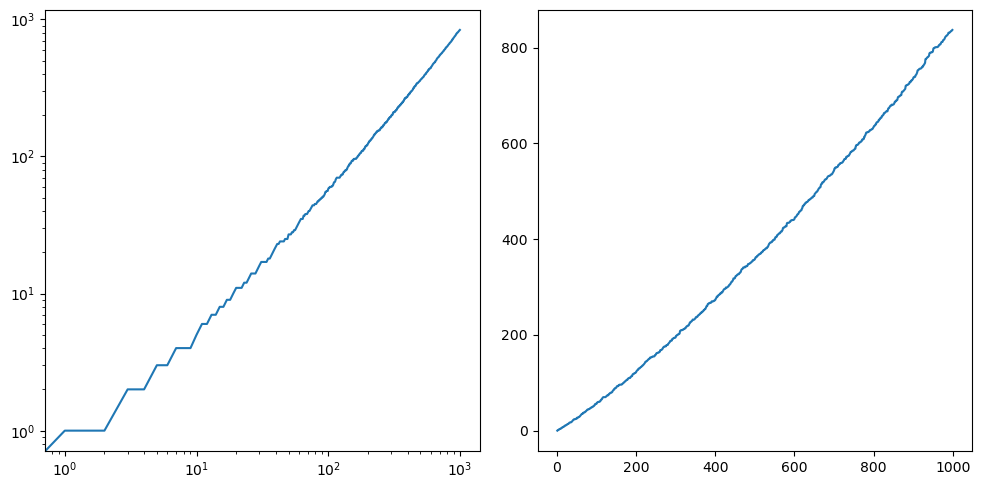

In [381]:
fig, ax = plt.subplots(figsize=(10, 5), ncols=2)
fig.tight_layout()
ax[1].plot(np.arange(1, k+1), x[:k])
ax[0].plot(x[:k])
ax[0].set_yscale("log")
ax[0].set_xscale("log")